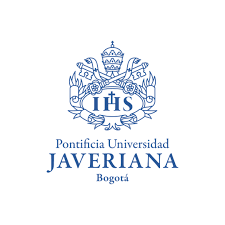
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Julian Andres Carrillo Chiquisa

Fecha de Inicio: 

Fecha actual: 

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

---

## Problemática

El tratamiento del agua es indispensable para garantizar su pureza y calidad. Este taller aplica los conceptos de **Procesamiento de Datos en Alto Volumen (PAVD)** para diagnosticar la calidad del agua en la India, abordando un problema de salud pública de escala nacional.

## Objetivo

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático **MLlib de PySpark** y redes neuronales con **Keras/TensorFlow**, con el fin de explorar técnicas de IA en entornos distribuidos de alto volumen de datos.

## Metodología

| Paso | Descripción |
|---|---|
| **1** | Importación de datos desde HDFS en formato CSV |
| **2** | Preprocesamiento: limpieza de nulos, conversión de tipos, EDA y estadísticas descriptivas |
| **3** | Ingeniería de características: cálculo de rangos de calidad (qr) por parámetro e índice WQI |
| **4** | Visualización: gráficas de parámetros, mapa georreferenciado por estado |
| **5** | Entrenamiento de modelos: red neuronal densa con Keras para predecir WQI |
| **6** | Evaluación: métricas de rendimiento (MSE, loss por época) |

---

## 1. Importación de Bibliotecas

Se importan todas las dependencias necesarias para el taller. El entorno corre sobre un cluster Spark, por lo que se usa **findspark** para localizar la instalación de Spark en el sistema antes de iniciar la sesión.

| Biblioteca | Propósito |
|---|---|
| `numpy`, `pandas` | Manipulación numérica y tabular en el driver local |
| `seaborn`, `matplotlib` | Visualización de datos |
| `findspark` | Localizar Spark instalado en el cluster |
| `pyspark.sql` | API de DataFrames distribuidos |
| `pyspark.sql.functions` | Funciones de transformación sobre columnas Spark |

In [1]:
import os
import sys
sys.path.append('/usr/lib/python3/dist-packages/')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *
import findspark
findspark.init()
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *

### Levantamiento de Sesión Spark

Se crea la sesión Spark con un nombre de aplicación identificable en la UI de Spark (`4040` por defecto). `SparkSession` es el punto de entrada único para trabajar con DataFrames, SQL y Streaming en Spark 2+.

> **Nota:** En un cluster ya configurado, `SparkSession.builder.getOrCreate()` reutiliza la sesión activa si ya existe, evitando duplicar contextos.

In [2]:
configura = SparkConf()
configura.setAppName("Calidad_Agua_Carrillo")
sparkCarrillo = SparkSession.builder.config(conf=configura).getOrCreate()
SQLContext(sparkContext=sparkCarrillo.sparkContext, sparkSession=sparkCarrillo)
sparkContextoS = sparkCarrillo.sparkContext.getOrCreate()
print("Sesion creada: ProcesamientoDatos03")
sparkCarrillo

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/27 23:26:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/27 23:26:46 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/27 23:26:46 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/05/27 23:26:46 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/05/27 23:26:46 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/05/27 23:26:46 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
26/05/27 23:26:46 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.
26/05/27 23:26:46 WARN Utils: Service 'SparkUI' could not bind on port 4046. Attempting port 4047.
26/05/27 23:26:46 WARN Utils: Serv

Sesion creada: ProcesamientoDatos03


---

## 2. Carga de Datos desde HDFS

Los datos se encuentran almacenados en el **Sistema de Archivos Distribuido Hadoop (HDFS)**, lo que permite que Spark los lea en paralelo desde múltiples nodos del cluster sin mover los datos al driver.

- El comando `hadoop fs -ls /csv` lista los archivos disponibles en HDFS.
- Se carga el CSV con cabecera (`header = true`) directamente desde la ruta HDFS usando la IP del NameNode.

> **Arquitectura:** `hdfs://10.195.34.34:9000` es el NameNode del cluster. Spark solicita los bloques de datos a los DataNodes automáticamente.

In [3]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkCarrillo.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

df00.show(5)

Found 11 items
-rw-r--r--   2 sistemas supergroup     977501 2026-03-10 15:27 /csv/CustomerChurn.csv
-rw-r--r--   2 sistemas supergroup      40868 2025-07-07 15:41 /csv/Fortune500USCompanies.csv
drwxr-xr-x   - sistemas supergroup          0 2025-10-16 14:17 /csv/auxiliar
-rw-r--r--   2 sistemas supergroup    4610348 2026-04-28 08:17 /csv/bank-full.csv
-rw-r--r--   2 sistemas supergroup      34635 2025-09-02 13:22 /csv/jugadores.csv
-rw-r--r--   2 sistemas supergroup    1082023 2025-09-02 13:22 /csv/resultados_futbol.csv
-rw-r--r--   2 sistemas supergroup     316971 2025-06-10 09:11 /csv/stroke_pyspark.csv
drwxr-xr-x   - sistemas supergroup          0 2025-06-18 15:36 /csv/taxi
drwxr-xr-x   - sistemas supergroup          0 2026-04-23 15:56 /csv/titanic
-rw-r--r--   2 sistemas supergroup      48036 2025-06-12 14:31 /csv/waterquality.csv
-rw-r--r--   2 sistemas supergroup      84199 2026-04-23 17:11 /csv/winequality-red.csv


[Stage 1:>                                                          (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

---

## 3. Análisis y Preparación de Datos

El dataset contiene mediciones de parámetros fisicoquímicos y biológicos de ríos de la India. Cada registro representa el **promedio de un período de medición** en una estación geográfica específica. Los datos provienen de la web oficial del gobierno indio (RiverIndia).

### 3.1 Descripción de Columnas

| Columna | Descripción | Unidad |
|---|---|---|
| `STATION CODE` | Código identificador de la estación de medición | — |
| `LOCATIONS` | Nombre del río o ubicación geográfica | — |
| `STATE` | Estado de la India donde se tomó la medición | — |
| `TEMP` | Temperatura del agua | °C |
| `DO` | Oxígeno Disuelto — valores altos indican mejor calidad | mg/L |
| `pH` | Logaritmo negativo de la concentración de H⁺ — indica acidez/basicidad | adimensional |
| `CONDUCTIVITY` | Capacidad de conducción eléctrica — el agua pura no conduce | µS/cm |
| `BOD` | Demanda Bioquímica de Oxígeno — mayor BOD indica mayor contaminación orgánica | mg/L |
| `NITRATE_N_NITRITE_N` | Concentración de nitratos/nitritos — altas concentraciones degradan la calidad | mg/L |
| `FECAL_COLIFORM` | Promedio de bacterias coliformes fecales — indicador de contaminación biológica | UFC/100mL |
| `TOTAL_COLIFORM` | ~~Se eliminará~~ — No aporta valor diferencial al modelo predictivo | UFC/100mL |

### Inspección de Columnas

Se verifican los nombres de columnas disponibles en el DataFrame Spark cargado desde HDFS.

In [4]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

### Estadísticas Descriptivas

Se calculan estadísticas básicas (count, mean, stddev, min, max) para cada columna individualmente usando `describe()`. Esto nos permite detectar rangos inusuales, posibles outliers y confirmar que los tipos de datos son consistentes.

In [5]:
for valor in df00.columns:
  df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+



+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+--------

### 3.2 Análisis de Valores Nulos

Se cuenta la cantidad de valores nulos o `NaN` por columna. En Spark, tanto `isNull()` como `isnan()` deben evaluarse: el primero detecta `null` de SQL, el segundo detecta `NaN` de punto flotante. Ambas condiciones se cubren con `F.when(F.isnan(c) | F.col(c).isNull(), c)`.

In [6]:
#Cantidad de Valores Nulos o Imposibles

df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



**Resultado esperado:** No se presentan valores nulos ni imposibles en las columnas de interés.

A continuación se crea una vista SQL filtrada explícitamente sobre los campos relevantes, como buena práctica de limpieza antes de las transformaciones posteriores.

In [7]:
df00.createOrReplaceTempView("df00_sql")

df01 = sparkCarrillo.sql('''
    SELECT * FROM df00_sql
    WHERE TEMP                IS NOT NULL
      AND DO                  IS NOT NULL
      AND pH                  IS NOT NULL
      AND CONDUCTIVITY        IS NOT NULL
      AND BOD                 IS NOT NULL
      AND NITRATE_N_NITRITE_N IS NOT NULL
      AND FECAL_COLIFORM      IS NOT NULL
''')

df01.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

**Verificación post-filtrado:** Se confirma que el DataFrame `df01` no contiene nulos.

In [8]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### 3.3 Tratamiento de Tipos de Datos

Cuando se lee un CSV con Spark sin especificar esquema, **todos los campos se infieren como `StringType`**, por lo tanto, es obligatorio convertirlos a tipos numéricos antes de aplicar operaciones matemáticas o entrenar modelos.

Por lo tanto, es necesario usar `.cast(FloatType())` para convertir cada columna numérica de tipo flotante. `FloatType` es suficiente para estos valores fisicoquímicos y reduce el uso de memoria frente a `DoubleType`.

**Inspección de tipos actuales (StringType esperado):**

In [9]:
df00.dtypes

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'string'),
 ('DO', 'string'),
 ('pH', 'string'),
 ('CONDUCTIVITY', 'string'),
 ('BOD', 'string'),
 ('NITRATE_N_NITRITE_N', 'string'),
 ('FECAL_COLIFORM', 'string'),
 ('TOTAL_COLIFORM', 'string')]

**Conversión de tipos a FloatType:**

In [10]:
df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
df00.dtypes

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'float'),
 ('DO', 'float'),
 ('pH', 'float'),
 ('CONDUCTIVITY', 'float'),
 ('BOD', 'float'),
 ('NITRATE_N_NITRITE_N', 'float'),
 ('FECAL_COLIFORM', 'float'),
 ('TOTAL_COLIFORM', 'string')]

### 3.4 Eliminación de Columna Irrelevante

La columna `TOTAL_COLIFORM` no aporta información diferencial respecto a `FECAL_COLIFORM` para el modelo predictivo de WQI, por lo tanto, se elimina para reducir la dimensionalidad y evitar multicolinealidad.

In [11]:
df01 = df00.drop('TOTAL_COLIFORM')
df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

---

## 4. Visualización de Parámetros

Para visualizar con Matplotlib los datos distribuidos en Spark, es necesario **colectarlos al driver** usando `.collect()`. Este paso trae los datos desde los ejecutores del cluster al nodo driver, lo que es viable para tamaños de datos manejables.

Se crea una vista temporal SQL (`df01_sql`) y se extraen vectores por parámetro usando la API RDD con funciones lambda.

**Creación de vista temporal SQL:**

In [12]:
df01.createOrReplaceTempView("df01_sql")

**Extracción de DataFrames por parámetro:**

Se ejecuta una consulta SQL por cada parámetro de interés para aislar sus valores.

In [13]:
do_parametro = sparkCarrillo.sql("Select DO from df01_sql")
ph_parametro = sparkCarrillo.sql("Select pH from df01_sql")
conductivity_parametro = sparkCarrillo.sql("Select CONDUCTIVITY from df01_sql")
BOD_parametro = sparkCarrillo.sql("Select BOD from df01_sql")
NITRATE_N_NITRITE_N_parametro = sparkCarrillo.sql("Select NITRATE_N_NITRITE_N from df01_sql")
FECAL_COLIFORM_parametro = sparkCarrillo.sql("Select FECAL_COLIFORM from df01_sql")

**Recolección de valores al driver con RDD + lambda:**

La función `rdd.map(lambda fila: fila.COLUMNA).collect()` convierte el DataFrame Spark en una lista Python local, que es necesaria para las funciones de graficación de Matplotlib.

In [14]:
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect()
conductivity_parametro = conductivity_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()
NITRATE_N_NITRITE_N_parametro = NITRATE_N_NITRITE_N_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()
FECAL_COLIFORM_parametro = FECAL_COLIFORM_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()

### Gráfica: Oxígeno Disuelto (DO) y pH

Visualización comparativa de los dos parámetros de acidez/oxigenación a lo largo de las estaciones de medición.

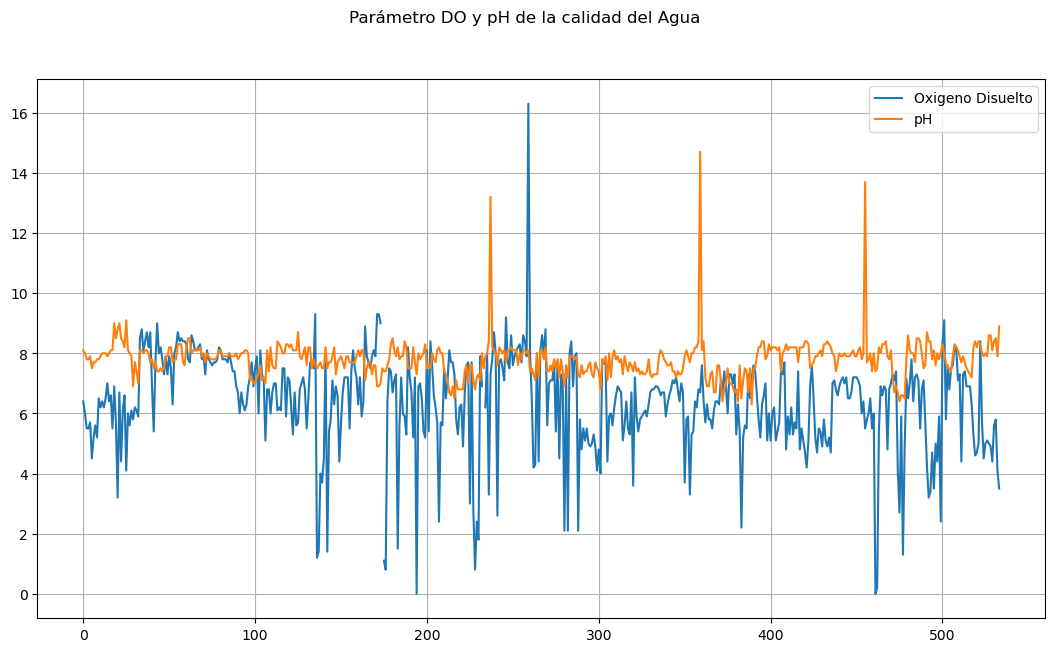

In [15]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_parametro, label='pH')
fig.suptitle('Parámetro DO y pH de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

### Gráfica: Demanda Bioquímica de Oxígeno (BOD) y Nitratos

El BOD alto junto a nitratos elevados es señal de contaminación orgánica y eutrofización.

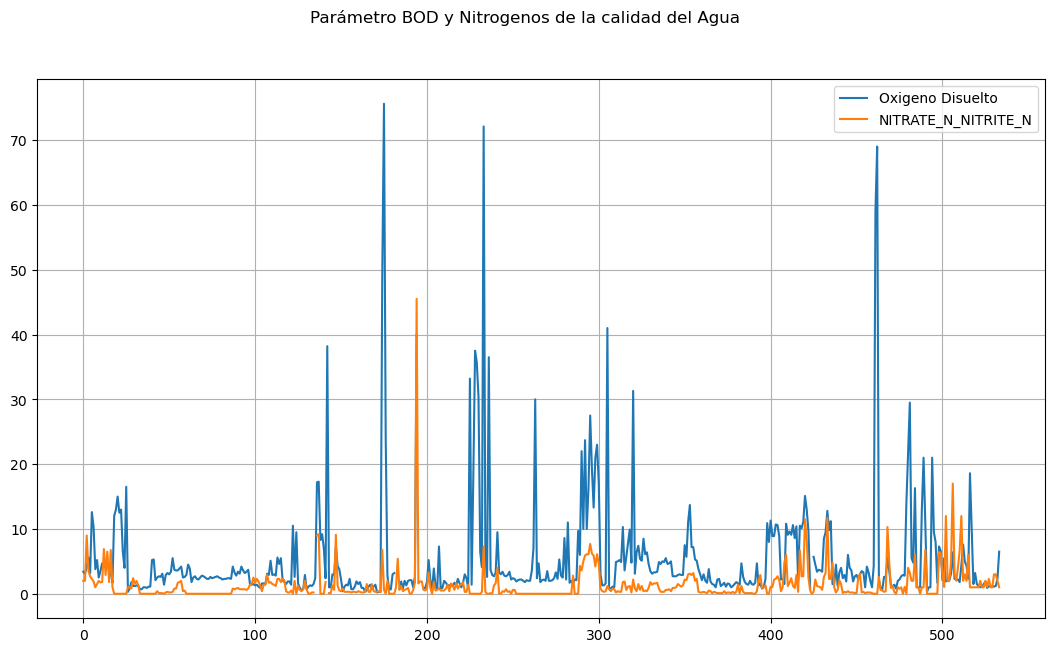

In [16]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), BOD_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), NITRATE_N_NITRITE_N_parametro, label='NITRATE_N_NITRITE_N')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

### Gráfica: Conductividad y Coliformes Fecales

La conductividad refleja la mineralización del agua; los coliformes fecales indican contaminación biológica.

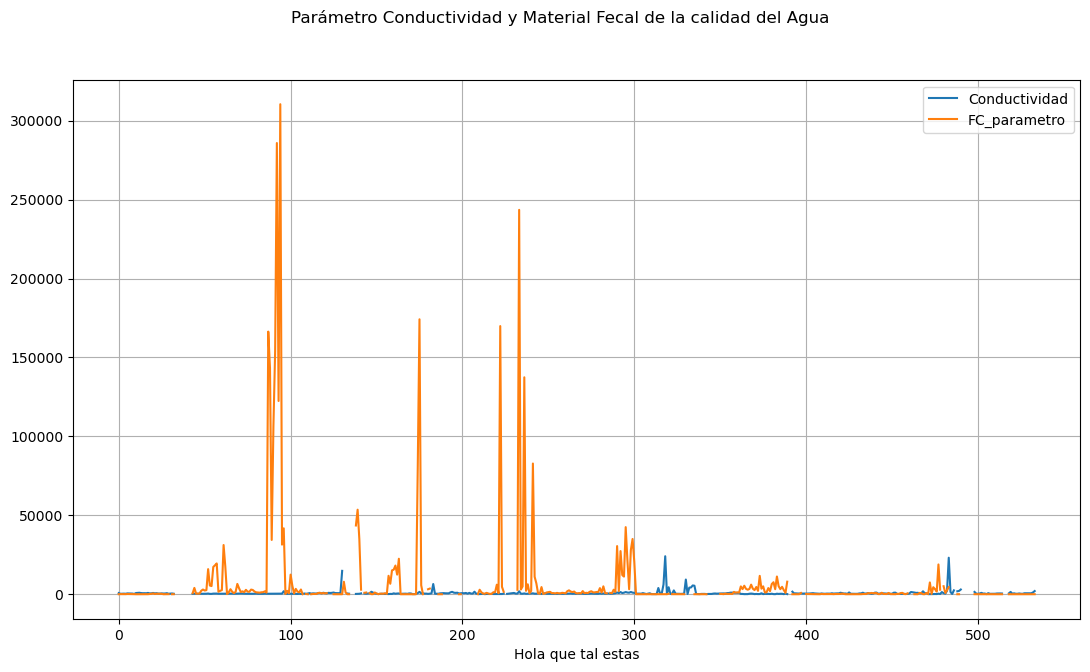

In [17]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), conductivity_parametro, label='Conductividad')
ax1.plot(range(0,tam), FECAL_COLIFORM_parametro, label='FC_parametro')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("Hola que tal estas")
plt.grid()
plt.show()

---

## 5. Ingeniería de Características: Rangos de Calidad (qr)

Según la referencia bibliográfica ([IntechOpen Cap. 69568](https://www.intechopen.com/chapters/69568)), cada parámetro fisicoquímico se convierte en un **puntaje de calidad discreto** entre 0 y 100 usando rangos estandarizados.

La lógica se implementa con `F.when(...).otherwise(0)` en Spark, equivalente a una sentencia `CASE WHEN` en SQL.

| Puntaje | Clasificación |
|---|---|
| **100** | Agua excelente / dulce |
| **80** | Agua buena / moderada |
| **60** | Agua regular / dura |
| **40** | Agua deficiente / muy dura |
| **0** | Agua inadecuada / fuera de rango |

### 5.1 Rango de Calidad por pH (`qrPH`)

El pH óptimo para agua potable según la OMS es entre 6.5 y 8.5. El puntaje máximo (100) se asigna al rango ideal de 7.0–8.5.

In [18]:
df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).

       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

### 5.2 Rango de Calidad por Oxígeno Disuelto (`qrDO`)

El DO refleja la capacidad del agua para sostener vida acuática. Valores por encima de 6.0 mg/L indican agua de alta calidad.

In [19]:
df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
                    when((df01.DO>=5.1) & (df01.DO<6.0), 80).
                    when((df01.DO>=4.1) & (df01.DO<5.0), 60).
                    when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

### 5.3 Rango de Calidad por Conductividad (`qrCOND`)

La conductividad eléctrica indica la cantidad de sales disueltas. Agua de baja conductividad (< 75 µS/cm) es considerada de alta pureza.

In [20]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
            when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
            when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
            when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

### 5.4 Rango de Calidad por BOD (`qrBOD`)

La Demanda Bioquímica de Oxígeno mide la contaminación orgánica. Valores bajos (< 3 mg/L) corresponden a agua limpia; valores altos indican descomposición orgánica activa.

In [21]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
                       when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
                       when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
                       when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

### 5.5 Rango de Calidad por Nitratos/Nitritos (`qrNN`)

Las concentraciones elevadas de nitrógeno (nitratos + nitritos) provocan eutrofización en cuerpos de agua y son tóxicas para humanos a partir de ciertos umbrales.

| Puntaje | Concentración |
|---|---|
| 100 | < 20 mg/L — Agua dulce |
| 80 | 20–50 mg/L — Moderada |
| 60 | 50–100 mg/L — Dura |
| 40 | 100–200 mg/L — Muy dura |

In [22]:
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
                       when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
                       when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
                       when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

### 5.6 Rango de Calidad por Coliformes Fecales (`qrFecal`)

Los coliformes fecales son el indicador biológico más directo de contaminación por aguas residuales. Su presencia en concentraciones elevadas hace el agua no apta para consumo humano.

| Puntaje | Concentración |
|---|---|
| 100 | < 5 UFC/100mL — Agua dulce |
| 80 | 5–50 UFC/100mL — Moderada |
| 60 | 50–500 UFC/100mL — Dura |
| 40 | > 500 UFC/100mL — Muy dura |

In [23]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
                       when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
                       when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
                       when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

### Inspección del DataFrame con Rangos de Calidad

El objeto `df02` contiene el dataset original más las 6 nuevas columnas de rangos de calidad (`qrPH`, `qrDO`, `qrCOND`, `qrBOD`, `qrNN`, `qrFecal`). Se verifica visualmente su contenido.

In [24]:
df02.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

**Nombres de columnas del DataFrame `df02`:**

In [25]:
df02.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

---

## 6. Cálculo del Índice de Calidad del Agua (WQI)

El **Water Quality Index (WQI)** es un índice compuesto que agrega múltiples parámetros en un único valor numérico ponderado. Permite clasificar la calidad del agua de forma comparable entre distintas estaciones y períodos.

### 6.1 Ponderación por Parámetro

Cada rango de calidad (qr) se multiplica por un **peso (w)** que refleja la importancia relativa del parámetro según la literatura de referencia:

| Parámetro | Variable | Peso |
|---|---|---|
| pH | `wpH` | 0.165 |
| Oxígeno Disuelto | `wDO` | 0.281 |
| Conductividad | `wCOND` | 0.234 |
| BOD | `wBOD` | 0.009 |
| Nitratos/Nitritos | `wNN` | 0.028 |
| Coliformes Fecales | `wFecal` | 0.281 |

> **Nota:** La suma de los pesos es ≈ 0.998, representando la casi totalidad del índice compuesto.

In [26]:
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

In [27]:
df03.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

In [28]:
df03.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### 6.2 Cálculo del WQI Final

El WQI se obtiene sumando los valores ponderados de cada parámetro. El resultado se redondea a 3 decimales.

In [29]:
df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

### 6.3 Clasificación por Etiqueta de Calidad

Se asigna una etiqueta categórica a cada registro según el rango del WQI calculado:

| Etiqueta | Rango WQI | Interpretación |
|---|---|---|
| `Excelente` | [0, 25) | Agua dulce, apta para consumo directo |
| `Buena` | [25, 50) | Agua moderada, requiere tratamiento mínimo |
| `Baja` | [50, 75) | Agua dura, requiere tratamiento convencional |
| `Muy_Baja` | [75, 100) | Agua muy dura, requiere tratamiento avanzado |
| `Inadecuada` | ≥ 100 | Agua residual, no apta sin tratamiento completo |

In [30]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
    .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
    .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
    .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
    .otherwise('Inadecuada')
                      )
df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

---

## 7. Visualización Geográfica: Mapa de la India

Se georreferencian los resultados de calidad del agua superponiéndolos sobre un **mapa vectorial de los estados de la India** usando GeoPandas.

### Flujo del proceso:

1. Extraer los estados únicos presentes en el dataset Spark
2. Cargar el shapefile de estados de la India con GeoPandas
3. Armonizar los nombres de estados entre ambas fuentes
4. Combinar los DataFrames (merge) por el campo `STATE`
5. Pintar el mapa con coloración por WQI

**Paso 1 — Extracción de estados únicos del dataset:**

In [31]:
colEstado = 'STATE'
valNomnbres = df05.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


**Paso 2 — Carga del shapefile con GeoPandas:**

Los archivos vectoriales de tipo shapefile están compuestos por 4 archivos que deben residir en la misma carpeta: `.shp` (geometría), `.dbf` (atributos), `.shx` (índice) y `.prj` (sistema de coordenadas).

In [37]:
import geopandas as gpd
rutaMapas = "Indian_States.shp"

In [38]:
gpd01 = gpd.read_file(rutaMapas)

**Inspección del GeoDataFrame:** tipo de objeto y columnas disponibles.

In [39]:
print(type(gpd01))

gpd01.columns

<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

**Nombres de estados en el shapefile (columna `st_nm`):**

In [40]:
gpd01["st_nm"].unique()

array(['Andaman & Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara & Nagar Havelli',
       'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Odisha',
       'Andhra Pradesh'], dtype=object)

**Paso 3 — Normalización de nombres de estados:**

Los nombres de estados difieren entre el shapefile y el dataset de calidad del agua (uso de `&` vs espacio, prefijos como `NCT of`, etc.). Se aplica un diccionario de reemplazos para garantizar el match en el merge posterior.

In [41]:
gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                     'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                    'Daman & Diu': 'Daman Diu', 
                     'Jammu & Kashmir': 'Jammu Kashmir',
                     'NCT of Delhi' : 'Delhi'
                    })
gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

**Paso 4 — Combinación de datos de calidad con geometría del mapa:**

- Se estandariza la columna `STATE` en el dataset Spark (corrección de `TAMILNADU → Tamil Nadu`).
- Se renombra `st_nm` a `STATE` en el GeoDataFrame.
- Se aplica un `outer join` por `STATE` para preservar todos los estados del mapa aunque no tengan medición.
- Se calculan puntos representativos dentro de cada geometría (para etiquetas de texto).
- Se eliminan duplicados por estado.

In [42]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [43]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### Mapa Inicial de la India

Se grafica el mapa base. Los estados sin datos de calidad de agua aparecen en gris claro (`lightgrey`).

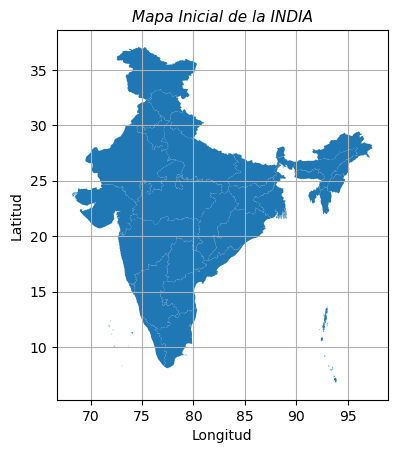

In [44]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

### Mapa con Etiquetas de Estado y Coloración por WQI

Para superponer etiquetas de texto sobre el mapa sin que se solapen, se usa la biblioteca **adjustText**. La coloración del mapa (`scheme='quantiles'`) distribuye los estados en grupos de igual tamaño según el WQI.

In [47]:
import subprocess, sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "adjustText",
    "--target", "/tmp/site-packages",
    "--quiet"
])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "mapclassify>=2.4.0",
    "--target", "/tmp/site-packages",
    "--quiet"
])

import sys
sys.path.insert(0, "/tmp/site-packages")

from adjustText import adjust_text

**Imputación de WQI nulos e impresión del mapa coloreado:**

Los estados sin medición reciben el valor mediano del WQI para no quedar vacíos en la visualización.

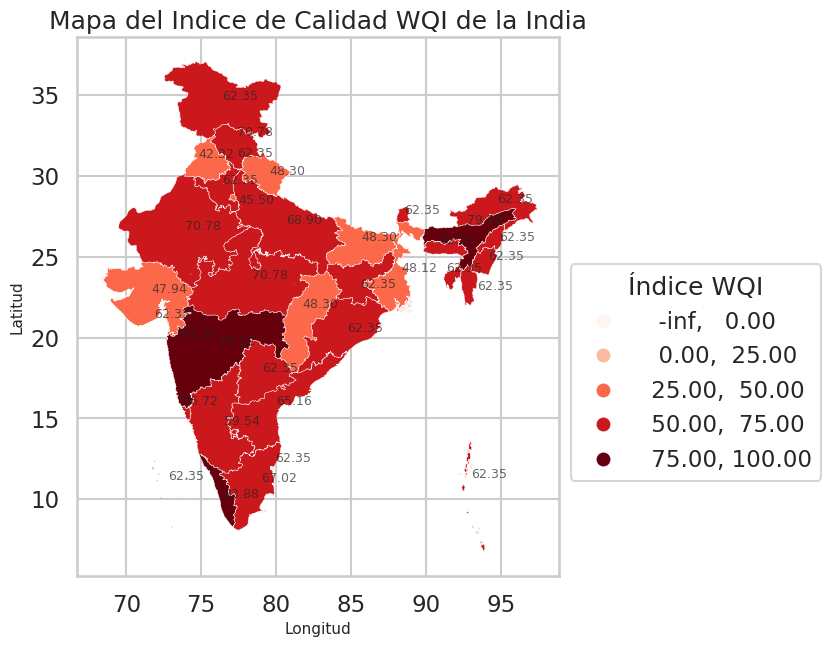

In [48]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

sns.set_context("talk")
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    

adjust_text(textos, ax=ax, force_points=(0.2, 0.2))
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

---

## 8. Histograma de WQI por Estado

Se visualiza el índice WQI de cada estado de la India como un gráfico de barras horizontal, facilitando la comparación entre regiones.

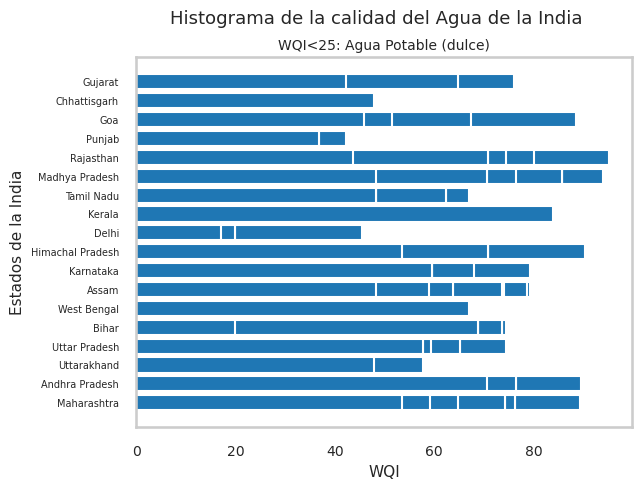

In [49]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
Estados = sparkCarrillo.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkCarrillo.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

---

## 9. Modelo Predictivo: Red Neuronal Densa (Keras)

Se entrena una **red neuronal completamente conectada (Dense Neural Network)** para predecir el valor numérico del WQI a partir de los 6 rangos de calidad calculados (`qrPH`, `qrDO`, `qrCOND`, `qrBOD`, `qrNN`, `qrFecal`).

### Arquitectura del modelo

| Capa | Neuronas | Activación | Descripción |
|---|---|---|---|
| Input + Hidden 1 | 350 | ReLU | Capa de entrada con 6 features |
| Hidden 2 | 350 | ReLU | Capa oculta intermedia |
| Hidden 3 | 350 | ReLU | Capa oculta profunda |
| Output | 1 | Linear | Salida continua (regresión) |

> **Nota:** `input_dim=6` corresponde a los 6 parámetros de calidad. La activación lineal en la capa de salida es correcta para problemas de regresión.

**Inspección de columnas del DataFrame final:**

In [50]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

### 9.1 Preparación de Datos para el Modelo

Se separan las variables predictoras (`X = rangos qr`) de la variable objetivo (`y = WQI`). Dado que Keras trabaja sobre arreglos NumPy/Pandas, se convierten los DataFrames Spark a Pandas con `.toPandas()`.

Luego se divide el dataset con `train_test_split` de Scikit-Learn: **80% entrenamiento / 20% prueba**, con semilla aleatoria fija (`random_state=1`) para reproducibilidad.

In [51]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [52]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

**Verificación del tamaño de los conjuntos de datos:**

In [53]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


### 9.2 Importación de Keras y Construcción del Modelo

Se usa la API **Sequential** de Keras para apilar capas densas. Esta API es adecuada para redes donde la información fluye linealmente de entrada a salida.

In [54]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

I0000 00:00:1779942719.527231 1235073 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [55]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 200
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

/opt/conda/envs/rapKernel_v4/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1779942723.534639 1235073 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### 9.3 Compilación del Modelo

- **Optimizador:** Adam con `learning_rate=0.001` — adaptativo, robusto ante gradientes dispersos.
- **Función de pérdida:** `mean_squared_error` (MSE) — métrica estándar para regresión.
- **Métrica de monitoreo:** `mse` — permite rastrear el error durante el entrenamiento.

In [56]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

**Resumen de la arquitectura del modelo:**

In [57]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

### 9.4 Entrenamiento del Modelo

- **Épocas:** 200 — número de pasadas completas sobre el conjunto de entrenamiento.
- **Batch size:** 81 — número de muestras procesadas antes de actualizar los pesos.

El historial de entrenamiento (`ejecutarK.history`) permite graficar la curva de pérdida.

In [58]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1254.5155 - mse: 1254.5155  
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 228.4249 - mse: 228.4249
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 93.3974 - mse: 93.3974   
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41.4766 - mse: 41.4766 
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.8482 - mse: 19.8482 
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.5560 - mse: 11.5560 
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.4770 - mse: 5.4770 
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.0342 - mse: 3.0342 
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5779 - mse: 1.5779 
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9515 - mse: 0.9515 
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6189 - mse: 0.6189 
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4383 - mse: 0.4383 
Epoch 13/200
6/6 ━━━━━━━━━━━━

### 9.5 Visualización de la Curva de Pérdida

La curva de pérdida (loss) por época permite evaluar si el modelo converge correctamente. Una curva descendente y estabilizada indica un entrenamiento exitoso.

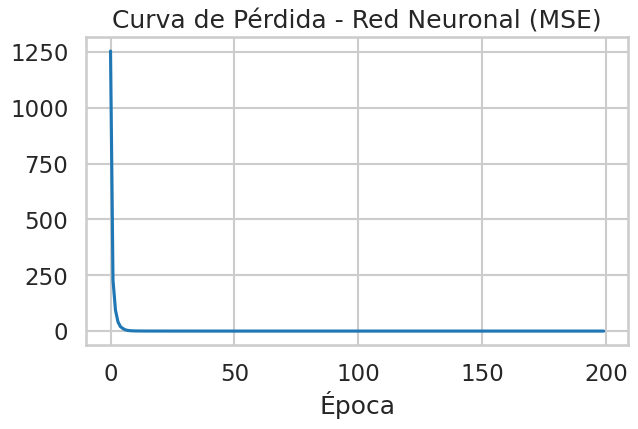

In [59]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("Curva de Pérdida - Red Neuronal (MSE)")
plt.xlabel("Época")
plt.show()

### 9.6 Predicción sobre Datos de Entrenamiento

Se evalúa la capacidad del modelo generando predicciones sobre el conjunto de entrenamiento y comparándolas visualmente con los valores reales.

In [60]:
# Se requiere predecir sobre los datos del entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


**Visualización de predicciones vs valores reales:**

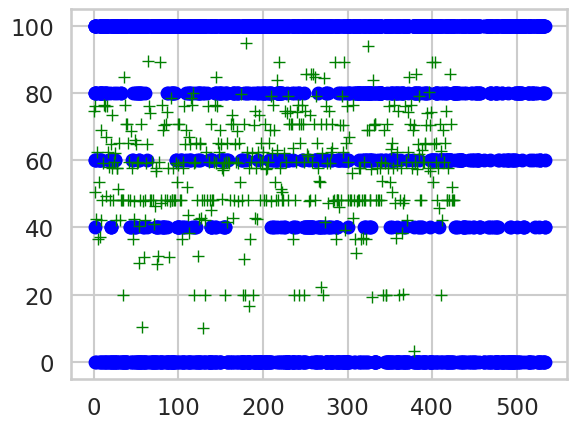

In [61]:
# Se pinta la predicción
plt.plot(dataTrain, 'bo', predModelo01_Train, 'g+')
plt.show()